In [2]:
import numpy as np
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt

about 500 will be significant: 10000 x 0.05, bellcurve around 0.5 if all values lay between 0 and 1
Prediction was partly wrong: 544 were false positives so this part was predicted right, but we see a uniformly distributed histogram instead of a bellcurve. 

In [7]:
rng = np.random.default_rng(42)
group_a = rng.normal(size=(10000, 5))
group_b = rng.normal(size=(10000, 5))

In [8]:
group_a.shape

(10000, 5)

In [16]:
results = stats.ttest_ind(group_a, group_b,axis=1)
p_values = results.pvalue

In [17]:
p_values.shape

(10000,)

In [19]:
significant = (p_values < 0.05)
significant.sum()

np.int64(544)

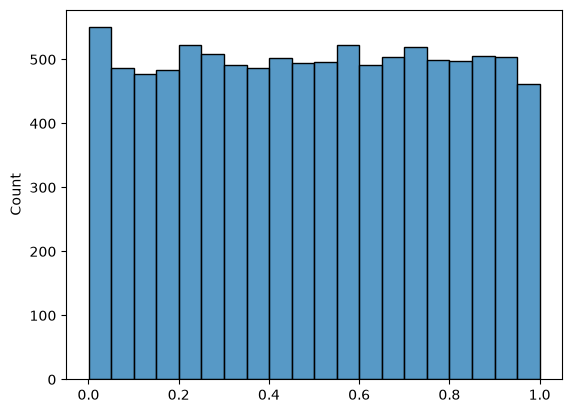

In [22]:
histogram = sns.histplot(p_values, bins=20)

As seen the 10000 tests are uniformly distributed over all the p-values. We see the biggest peak at the lowest p-value but this will be normal sampling noise. A p-value is just the chance to get a certain place on the curve and if nothing is going on then every chance is the same. with p = 0.5 that means that 50 percent of p-values should fall below it. If p = 0.8, 80 percent falls below it. So with 10000 tests and p = 0.05, we expect 500 tests to be false positives. 